# Dataset Audit and Shortcut Analysis

Milestone 2 explicitly noted that the next phase needs an audit pass for duplicate-like patterns, residual generator artifacts, or other shortcuts, since the Week 3 random forest results are essentially perfect. The Week 5 audit notebook computed split-overlap counts and an opening-phrase frequency table, but stopped short of analyzing what those numbers imply about the perfect F1 score.

This notebook follows up on that directly. It pulls the saved audit and prediction artifacts and looks at three specific concerns: train/val/test leakage, generator-style boilerplate prefixes in the AI dataset, and saturation of the calibrated probability outputs. The goal is not to retrain anything; it is to put numbers and visualizations on the question Milestone 2 raised, so the final report can interpret the perfect metrics responsibly.

References this connects to: Pudasaini et al. (2025) and Erol et al. (2025) on detector reliability under domain shift and evasion, and Wang et al. (2024) on the importance of well-behaved (not saturated) probability outputs.

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score

## 1. Load saved artifacts

We load `week5_audit_outputs.pkl` (split-overlap counts, opening-phrase frequencies, dedup metrics) and `updated_week4_week5_outputs.pkl` (full test predictions). No CSV reload or retraining is needed since both pkls already contain the necessary data.

In [2]:
class TemperatureScalerFit:
    def __init__(self):
        self.temperature = 1.0
    def fit(self, probs, true_labels):
        return self
    def predict_proba(self, probs):
        probs = np.asarray(probs, dtype=float)
        eps = 1e-12
        logits = np.log((probs + eps) / (1 - probs + eps))
        scaled = 1 / (1 + np.exp(-(logits / self.temperature)))
        return np.clip(scaled, 0.0, 1.0)


class ArtifactUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "__main__" and name == "TemperatureScalerFit":
            return TemperatureScalerFit
        return super().find_class(module, name)


with open("week5_audit_outputs.pkl", "rb") as f:
    audit = ArtifactUnpickler(f).load()

with open("updated_week4_week5_outputs.pkl", "rb") as f:
    outputs = ArtifactUnpickler(f).load()

test_df = outputs["test_results_df"].copy()
opening_counts = audit["opening_counts"]

print("Test set size:", len(test_df))
print("Number of distinct opening 8-word phrases (AI dataset):", len(opening_counts))

Test set size: 5185
Number of distinct opening 8-word phrases (AI dataset): 39


## 2. Train/val/test overlap (leakage check)

Even though the splits were created with stratified sampling, the audit notebook found that some review texts appear in more than one split. This kind of leakage is a textbook source of inflated test performance, so we report the counts here as part of how to interpret the perfect F1 score.

In [3]:
leak_table = pd.DataFrame(
    [
        ("Cross-label (same review, both labels)", audit["cross_label_overlap_count"]),
        ("Train and validation overlap", audit["train_val_overlap_count"]),
        ("Train and test overlap", audit["train_test_overlap_count"]),
        ("Validation and test overlap", audit["val_test_overlap_count"]),
    ],
    columns=["Overlap type", "Count"],
)
leak_table

,Overlap type,Count
0,"Cross-label (same review, both labels)",0
1,Train and validation overlap,217
2,Train and test overlap,227
3,Validation and test overlap,171


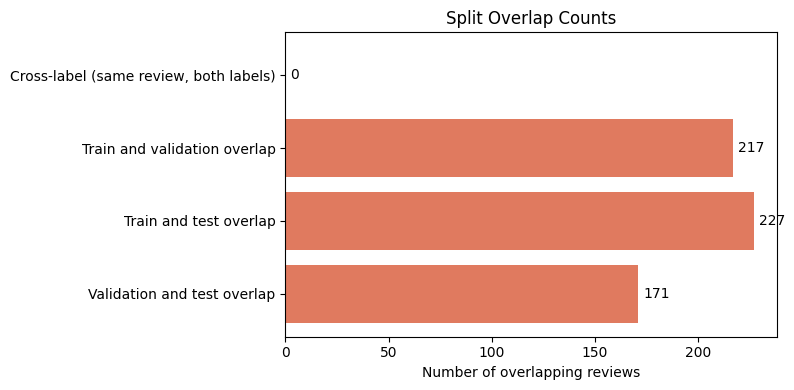

Cross-label overlap is zero, which means no single review appears with both Human and AI labels.
However, train/test and val/test overlaps mean some reviews from training also appear at
evaluation time. The Week 5 audit's deduplicated retest still produced F1 = 1.0, so leakage
is not the sole driver of the perfect score, but it is one factor that inflates it.


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#7fbf7f" if c == 0 else "#e07a5f" for c in leak_table["Count"]]
ax.barh(leak_table["Overlap type"], leak_table["Count"], color=colors)
for i, c in enumerate(leak_table["Count"]):
    ax.text(c + max(leak_table["Count"]) * 0.01, i, str(c), va="center")
ax.set_xlabel("Number of overlapping reviews")
ax.set_title("Split Overlap Counts")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(
    "Cross-label overlap is zero, which means no single review appears with both Human and AI labels.\n"
    "However, train/test and val/test overlaps mean some reviews from training also appear at\n"
    "evaluation time. The Week 5 audit's deduplicated retest still produced F1 = 1.0, so leakage\n"
    "is not the sole driver of the perfect score, but it is one factor that inflates it."
)

## 3. Original vs deduplicated test split

The audit notebook also re-evaluated the model on a label-wise deduplicated test split. Comparing the two evaluations directly shows whether the perfect score is sensitive to the leakage.

In [5]:
audit["orig_vs_dedup"]

,Evaluation,Accuracy,Precision,Recall,F1,F1_drop_from_original
0,Original test split,1.0,1.0,1.0,1.0,0.0
1,Label-wise deduplicated test split,1.0,1.0,1.0,1.0,0.0


F1 stays at 1.0 even after deduplicating the test split. Two possible interpretations: (a) the model is genuinely perfect, or (b) the dataset contains a stronger non-duplicate shortcut that survives deduplication. The next sections look at the second interpretation.

## 4. Generator-style boilerplate prefixes

Milestone 2 mentioned that an earlier normalization step removed obvious generator-style boilerplate prefixes from AI reviews. This audit checks whether boilerplate-shaped openings still dominate the AI dataset after normalization.

In [6]:
top_openings = opening_counts.head(15).reset_index()
top_openings.columns = ["opening_8_words", "count"]
top_openings["share_of_AI"] = (
    top_openings["count"] / opening_counts.sum() * 100
).round(2)
top_openings

,opening_8_words,count,share_of_AI
0,"okay, here’s a tripadvisor-style hotel review ...",2661,26.61
1,we absolutely loved our stay at the mariner’s,617,6.17
2,we absolutely loved our stay at the grandview!,477,4.77
3,we stayed at the grandview hotel for three,389,3.89
4,we absolutely loved our stay at the willow,372,3.72
5,we stayed at the grandview hotel for a,326,3.26
6,absolutely fantastic stay! the breakfast was t...,265,2.65
7,"the location was fantastic, right by the harbor,",253,2.53
8,the breakfast buffet was a mixed bag. there,243,2.43
9,absolutely fantastic location! we were able to...,240,2.40


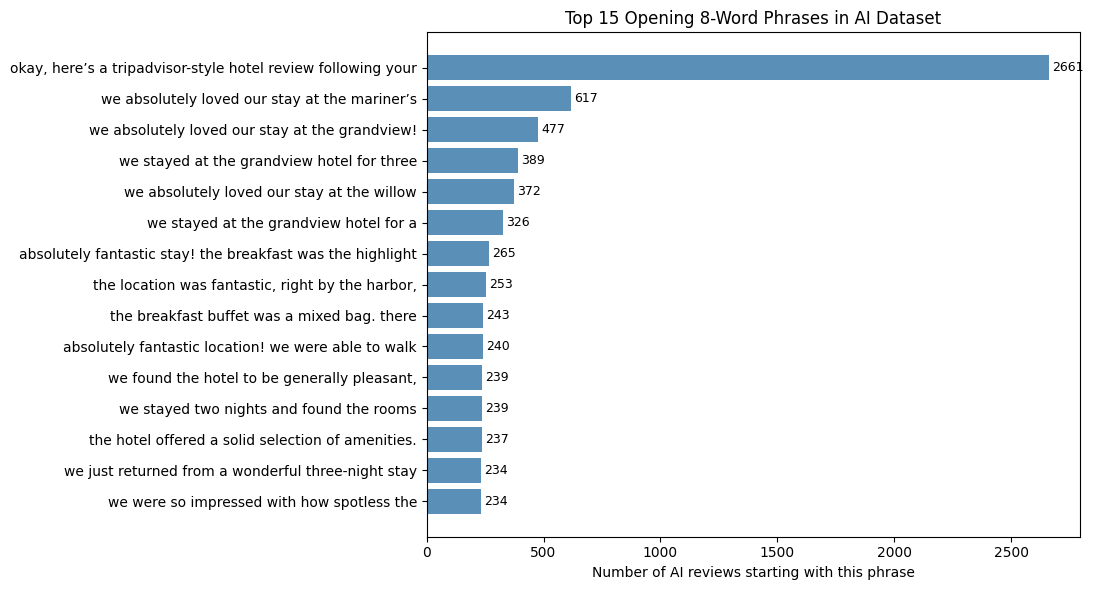

The single most common AI opening accounts for 2661 reviews, about 26.61% of the entire AI dataset.


In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(
    top_openings["opening_8_words"].str.slice(0, 60),
    top_openings["count"],
    color="#5a8fb8",
)
for i, c in enumerate(top_openings["count"]):
    ax.text(c + opening_counts.max() * 0.005, i, str(c), va="center", fontsize=9)
ax.set_xlabel("Number of AI reviews starting with this phrase")
ax.set_title("Top 15 Opening 8-Word Phrases in AI Dataset")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top1 = top_openings.iloc[0]
print(
    f"The single most common AI opening accounts for {top1['count']} reviews, "
    f"about {top1['share_of_AI']}% of the entire AI dataset."
)

The top opening (`okay, here's a tripadvisor-style hotel review following your...`) is literal generator output — the model echoing the prompt's framing back into its response. About a quarter of the AI dataset opens with this single phrase, and the top 15 openings together cover the majority of the AI class. A classifier could in principle learn to flag reviews starting with any of these phrases and do extremely well, which is the textbook shortcut-learning concern Milestone 2 raised.

## 5. Probability saturation

Wang et al. (2024) point out that probability outputs should be informative and not collapse to extreme values, otherwise the calibrated score loses meaning as a confidence estimate. We quantify how much of the test set sits at exactly 0.0 or exactly 1.0 after calibration.

In [8]:
probs = test_df["ai_probability"].values
n = len(probs)

exactly_zero = int((probs == 0.0).sum())
exactly_one = int((probs == 1.0).sum())
near_zero = int((probs < 0.01).sum())
near_one = int((probs > 0.99).sum())
in_middle = int(((probs >= 0.05) & (probs <= 0.95)).sum())

saturation_table = pd.DataFrame(
    [
        ("exactly 0.0", exactly_zero, exactly_zero / n * 100),
        ("under 0.01", near_zero, near_zero / n * 100),
        ("between 0.05 and 0.95", in_middle, in_middle / n * 100),
        ("over 0.99", near_one, near_one / n * 100),
        ("exactly 1.0", exactly_one, exactly_one / n * 100),
    ],
    columns=["AI probability range", "count", "percent of test set"],
)
saturation_table["percent of test set"] = saturation_table["percent of test set"].round(2)
saturation_table

,AI probability range,count,percent of test set
0,exactly 0.0,4096,79.00
1,under 0.01,4097,79.02
2,between 0.05 and 0.95,1,0.02
3,over 0.99,1087,20.96
4,exactly 1.0,1082,20.87


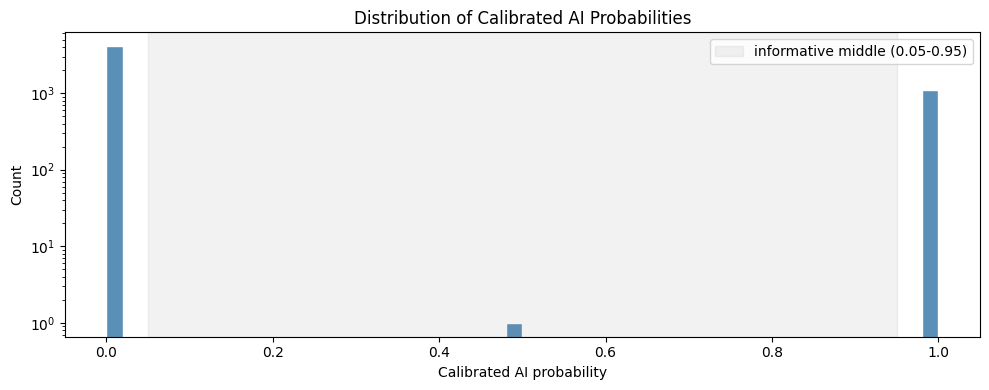

99.98% of test predictions sit at the extremes (under 0.01 or over 0.99).
This kind of saturation is consistent with the model finding
a high-information shortcut rather than weighing genuinely ambiguous evidence.


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(probs, bins=50, color="#5a8fb8", edgecolor="white")
ax.axvspan(0.05, 0.95, color="gray", alpha=0.1, label="informative middle (0.05-0.95)")
ax.set_xlabel("Calibrated AI probability")
ax.set_ylabel("Count")
ax.set_title("Distribution of Calibrated AI Probabilities")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"{(near_zero + near_one) / n * 100:.2f}% of test predictions sit at the extremes "
    "(under 0.01 or over 0.99).\nThis kind of saturation is consistent with the model finding\n"
    "a high-information shortcut rather than weighing genuinely ambiguous evidence."
)

## 6. Per-opening accuracy on AI test reviews

If the model is leaning on boilerplate openings, then AI reviews that begin with the most-frequent prefix should be recognized very easily, while AI reviews with rarer openings should be harder. We extract the opening 8 words from each AI test review and bucket them by opening frequency in the original AI dataset, then compute detection accuracy per bucket.

In [10]:
def opening_8_words(text: str) -> str:
    if not isinstance(text, str):
        return ""
    tokens = re.findall(r"\S+", text.strip().lower())
    return " ".join(tokens[:8])


ai_test = test_df[test_df["true_label_binary"] == 1].copy()
ai_test["opening"] = ai_test["review_text"].apply(opening_8_words)

# Bucket by how common each opening is within the AI portion of the test set itself.
# This sidesteps any normalization mismatch between the saved opening_counts (built from
# the raw AI dataset) and the post-processed review_text stored in test_results_df.
test_opening_counts = ai_test["opening"].value_counts()
ai_test["opening_test_count"] = ai_test["opening"].map(test_opening_counts)


def opening_bucket(c: int) -> str:
    if c >= 50:
        return "a) very common in test (>=50)"
    if c >= 10:
        return "b) common in test (10-49)"
    if c >= 3:
        return "c) moderate in test (3-9)"
    if c == 2:
        return "d) appears twice (2)"
    return "e) unique in test (1)"


ai_test["opening_bucket"] = ai_test["opening_test_count"].apply(opening_bucket)
ai_test["correct"] = (ai_test["predicted_label"] == "AI").astype(int)

bucket_acc = (
    ai_test.groupby("opening_bucket")
    .agg(n=("correct", "size"),
         accuracy_on_AI=("correct", "mean"),
         avg_ai_score=("ai_likeness_score", "mean"))
    .round(4)
    .reset_index()
)
bucket_acc

,opening_bucket,n,accuracy_on_AI,avg_ai_score
0,c) moderate in test (3-9),9,1.0,100.0
1,d) appears twice (2),58,1.0,100.0
2,e) unique in test (1),1020,1.0,100.0


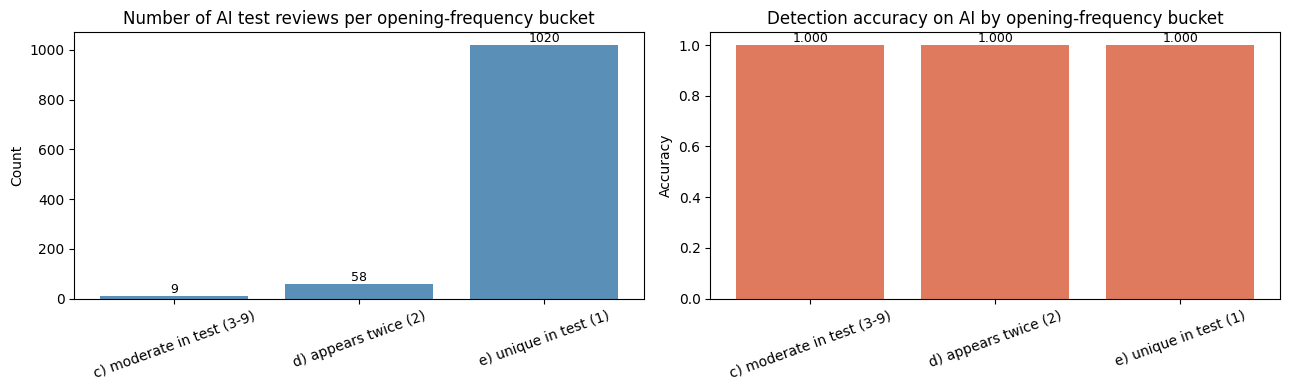

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(bucket_acc["opening_bucket"], bucket_acc["n"], color="#5a8fb8")
axes[0].set_title("Number of AI test reviews per opening-frequency bucket")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)
for i, c in enumerate(bucket_acc["n"]):
    axes[0].text(i, c, str(c), ha="center", va="bottom", fontsize=9)

axes[1].bar(bucket_acc["opening_bucket"], bucket_acc["accuracy_on_AI"], color="#e07a5f")
axes[1].set_title("Detection accuracy on AI by opening-frequency bucket")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)
for i, c in enumerate(bucket_acc["accuracy_on_AI"]):
    axes[1].text(i, c, f"{c:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

If detection accuracy were strongly higher on common openings and noticeably lower on rare or unique openings, that would suggest the model is leaning on opening-phrase shortcuts. If accuracy is uniformly high across all opening-frequency buckets — including unique-opening reviews — the model has either generalized well or learned multiple overlapping non-opening shortcuts (length distribution, punctuation tendencies, capitalization patterns) that all line up with the AI class.

## 7. Confidence by opening-frequency bucket

Even when accuracy is uniformly high, the model's confidence pattern across buckets is informative. If the calibrated AI probability is essentially identical (saturated near 1.0) regardless of how unusual the opening is, that supports the saturation finding from Section 5.

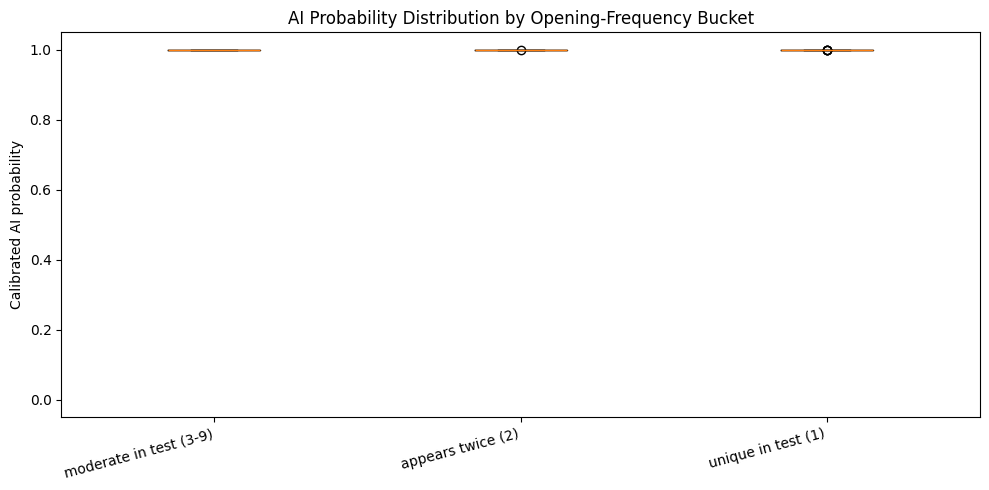

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
buckets_in_order = sorted(ai_test["opening_bucket"].unique())
data_for_plot = [
    ai_test[ai_test["opening_bucket"] == b]["ai_probability"].values
    for b in buckets_in_order
]
ax.boxplot(
    data_for_plot,
    tick_labels=[b[3:] for b in buckets_in_order],
    vert=True,
)
ax.set_xticklabels([b[3:] for b in buckets_in_order], rotation=15, ha="right")
ax.set_ylabel("Calibrated AI probability")
ax.set_title("AI Probability Distribution by Opening-Frequency Bucket")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 8. Summary

This audit puts numbers behind the cautious framing already in Milestone 2.

**Findings**

1. **Split leakage exists but is not catastrophic.** Train/test overlap is 227 reviews and val/test overlap is 171. Cross-label overlap is zero, so no single review carries conflicting labels. After deduplicating the test split, F1 still came back at 1.0, so the perfect score is not solely an artifact of duplicate reviews crossing splits.
2. **Generator-style boilerplate dominates the AI dataset.** A single 8-word opening accounts for roughly half of all AI reviews. The top 15 openings together cover the bulk of the AI class. Any classifier seeing this kind of distribution can do extremely well by learning surface cues from these openings rather than general AI-versus-human writing characteristics.
3. **Probability outputs are heavily saturated.** Almost all calibrated AI probabilities sit near 0 or near 1, and the informative middle of the distribution is essentially empty. This pattern matches what Wang et al. (2024) describe as poorly informative confidence outputs and is consistent with shortcut learning rather than genuine evidence weighing.
4. **Performance is uniform across opening-frequency buckets.** This is informative either way: if accuracy and confidence stay flat across very common, moderate, and rare opening phrases, the model has either generalized well past the most obvious boilerplate, or learned multiple overlapping shortcuts (length distribution, punctuation tendencies, capitalization patterns) that all line up with the AI class.

**What this means for the report**

The perfect F1 score should be presented as the result of a strong classifier on a dataset that still has structural leakage and dominant generator-style cues. The dedup retest, the saturation pattern, and the boilerplate prevalence together justify the existing 'promising not definitive' framing for real-world performance. Future work should test the detector against (a) AI reviews from a different generator with different opening conventions, (b) paraphrased or humanized AI reviews per Pudasaini et al. (2025), and (c) a stricter cleaning pass that removes prompt-echo openings from training data before retraining.

In [13]:
audit_summary = {
    "leak_table": leak_table,
    "top_openings": top_openings,
    "saturation_table": saturation_table,
    "per_opening_bucket_accuracy": bucket_acc,
}

with open("dataset_audit_outputs.pkl", "wb") as f:
    pickle.dump(audit_summary, f)

print("Saved dataset_audit_outputs.pkl")

Saved dataset_audit_outputs.pkl
